# DIAML Assignment 5: Financial Understanding of DJIA Component Companies
**Student: cbyabush**
**Student: Murhula Byabushi Christian**

**Topics Covered:** PCA, Clustering, Time Series Forecasting

## Libraries Used

In [103]:
# Required Libraries for Assignment 5
import yfinance as yf                          # For downloading stock data from Yahoo Finance
import pandas as pd                            # For data manipulation and DataFrames
import numpy as np                             # For numerical computations
import matplotlib.pyplot as plt                # For creating visualizations
import seaborn as sns                          # For statistical visualizations
from sklearn.decomposition import PCA          # For Principal Component Analysis
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # For data normalization
from sklearn.cluster import AgglomerativeClustering  # For hierarchical clustering
import scipy.cluster.hierarchy as shc         # For dendrogram and linkage
from scipy.spatial.distance import squareform  # For distance matrix conversion
from statsmodels.tsa.stattools import adfuller # For stationarity testing
from statsmodels.tsa.seasonal import seasonal_decompose, STL  # For decomposition
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # For ACF/PACF plots
from statsmodels.tsa.arima.model import ARIMA  # For ARIMA modeling
from statsmodels.tsa.statespace.sarimax import SARIMAX  # For SARIMA modeling
from sklearn.metrics import mean_absolute_error, mean_squared_error  # For error metrics
import warnings
warnings.filterwarnings('ignore')              # Suppress warnings for cleaner output

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("All libraries imported successfully!")

All libraries imported successfully!


---
# QUESTION 1: Principal Component Analysis (30%)
---

## 1.1 Qualitative Description of PCA and Log Returns

### What is Principal Component Analysis (PCA)?

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a set of correlated variables into a smaller set of uncorrelated variables called principal components. Each principal component is a linear combination of the original variables, ordered by the amount of variance they explain.

### PCA's Utility in Financial Machine Learning:

1. **Risk Factor Identification**: PCA extracts latent market factors (e.g., market risk, sector risk) from correlated asset returns
2. **Portfolio Construction**: Reduces dimensionality while preserving portfolio variance structure
3. **Noise Reduction**: Separates signal from noise by focusing on components with high explanatory power
4. **Multicollinearity Handling**: Creates orthogonal features for regression models

### Why Logarithmic Returns Instead of Arithmetic Returns?

Financial time-series data is typically transformed into logarithmic returns for three key reasons:

1. **Time-Additivity**: Multi-period log returns equal the sum of single-period returns:
   - $r_{t,t+n} = \ln(P_{t+n}/P_t) = \sum_{i=0}^{n-1} r_{t+i}$
   - This makes aggregating returns straightforward

2. **Numerical Symmetry**: Log returns treat gains and losses symmetrically:
   - A +10% gain followed by -10% loss gives the same result as -10% followed by +10%
   - This is not true for arithmetic returns

3. **Statistical Normality**: Log returns are approximately normally distributed:
   - Essential for PCA which assumes multivariate normality
   - Better statistical properties for hypothesis testing

## 1.2 Data Retrieval and Correlation Analysis

In [104]:
# Define the 30 constituents of the Dow Jones Industrial Average (as of December 2024)
# Source: S&P Dow Jones Indices
djia_tickers = [
    'AAPL',   # Apple Inc. - Technology
    'AMGN',   # Amgen Inc. - Healthcare
    'AMZN',   # Amazon.com Inc. - Consumer Discretionary
    'AXP',    # American Express Company - Financials
    'BA',     # Boeing Company - Industrials
    'CAT',    # Caterpillar Inc. - Industrials
    'CRM',    # Salesforce Inc. - Technology
    'CSCO',   # Cisco Systems Inc. - Technology
    'CVX',    # Chevron Corporation - Energy
    'DIS',    # Walt Disney Company - Communication Services
    'GS',     # Goldman Sachs Group Inc. - Financials
    'HD',     # Home Depot Inc. - Consumer Discretionary
    'HON',    # Honeywell International Inc. - Industrials
    'IBM',    # IBM Corporation - Technology
    'JNJ',    # Johnson & Johnson - Healthcare
    'JPM',    # JPMorgan Chase & Co. - Financials
    'KO',     # Coca-Cola Company - Consumer Staples
    'MCD',    # McDonald's Corporation - Consumer Discretionary
    'MMM',    # 3M Company - Industrials
    'MRK',    # Merck & Co. Inc. - Healthcare
    'MSFT',   # Microsoft Corporation - Technology
    'NKE',    # Nike Inc. - Consumer Discretionary
    'NVDA',   # NVIDIA Corporation - Technology
    'PG',     # Procter & Gamble Company - Consumer Staples
    'SHW',    # Sherwin-Williams Company - Materials
    'TRV',    # Travelers Companies Inc. - Financials
    'UNH',    # UnitedHealth Group Inc. - Healthcare
    'V',      # Visa Inc. - Financials
    'VZ',     # Verizon Communications Inc. - Communication Services
    'WMT'     # Walmart Inc. - Consumer Staples
]

print(f"DJIA Constituents: {len(djia_tickers)} stocks")
print(djia_tickers)

DJIA Constituents: 30 stocks
['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SHW', 'TRV', 'UNH', 'V', 'VZ', 'WMT']


In [105]:
# Download historical data for 2+ years using yfinance API
# Date range: January 2022 to December 2024 (approximately 3 years)
start_date = '2022-01-01'
end_date = '2024-12-01'

print(f"Downloading data from {start_date} to {end_date}...")

# Download all DJIA stock data
djia_data = yf.download(djia_tickers, start=start_date, end=end_date, progress=True)

# Extract closing prices
closing_prices = djia_data['Close']

# Display summary statistics
print(f"\n{'='*60}")
print("DATA SUMMARY")
print('='*60)
print(f"Shape: {closing_prices.shape}")
print(f"Date range: {closing_prices.index[0].strftime('%Y-%m-%d')} to {closing_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Number of trading days: {len(closing_prices)}")

[********              17%                       ]  5 of 30 completed

[*********************100%***********************]  30 of 30 completed


DATA SUMMARY
Shape: (732, 30)
Date range: 2022-01-03 to 2024-11-29
Number of trading days: 732


In [106]:
# Display first few rows of closing prices
print("First 5 rows of closing prices:")
print(closing_prices.head())

# Check for missing values
print(f"\nMissing values per stock:")
missing = closing_prices.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

First 5 rows of closing prices:
Ticker            AAPL        AMGN        AMZN         AXP          BA  \
Date                                                                     
2022-01-03  178.270325  199.659546  170.404495  159.976532  207.860001   
2022-01-04  176.007797  200.672409  167.522003  165.112274  213.630005   
2022-01-05  171.326004  198.294403  164.356995  163.352829  213.070007   
2022-01-06  168.465973  198.320786  163.253998  164.849731  211.339996   
2022-01-07  168.632538  200.187973  162.554001  166.260803  215.500000   

Ticker             CAT         CRM       CSCO         CVX         DIS  ...  \
Date                                                                   ...   
2022-01-03  192.158310  252.800751  56.096855  101.482437  154.189545  ...   
2022-01-04  202.443863  245.645996  54.721016  103.328957  153.176422  ...   
2022-01-05  203.994141  225.300034  53.854404  104.001198  152.645294  ...   
2022-01-06  206.073547  226.764618  54.426189  104.886177  

In [107]:
# Compute daily logarithmic returns
# Formula: r_t = ln(P_t / P_{t-1}) = ln(P_t) - ln(P_{t-1})
# Handle any missing values first
closing_prices = closing_prices.ffill().bfill()

# Calculate log returns
log_returns = np.log(closing_prices / closing_prices.shift(1))

# Remove first row (NaN due to shift operation)
log_returns = log_returns.dropna()

print("Daily Log Returns (first 5 rows):")
print(log_returns.head())
print(f"\nShape: {log_returns.shape}")

Daily Log Returns (first 5 rows):
Ticker          AAPL      AMGN      AMZN       AXP        BA       CAT  \
Date                                                                     
2022-01-04 -0.012773  0.005060 -0.017060  0.031599  0.027381  0.052143   
2022-01-05 -0.026960 -0.011921 -0.019074 -0.010713 -0.002625  0.007629   
2022-01-06 -0.016834  0.000133 -0.006734  0.009122 -0.008153  0.010142   
2022-01-07  0.000988  0.009371 -0.004297  0.008523  0.019493  0.009862   
2022-01-10  0.000116  0.013460 -0.006592 -0.003677 -0.029145 -0.011439   

Ticker           CRM      CSCO       CVX       DIS  ...      MSFT       NKE  \
Date                                                ...                       
2022-01-04 -0.028710 -0.024832  0.018032 -0.006592  ... -0.017296  0.010391   
2022-01-05 -0.086458 -0.015964  0.006485 -0.003473  ... -0.039144 -0.025196   
2022-01-06  0.006480  0.010561  0.008473  0.010958  ... -0.007933 -0.007486   
2022-01-07 -0.003673  0.003441  0.014258  0.005910  

In [108]:
# Calculate the Pearson correlation matrix for log returns
# Pearson correlation measures linear relationships between variables
correlation_matrix = log_returns.corr(method='pearson')

print(f"{'='*60}")
print("PEARSON CORRELATION MATRIX")
print('='*60)
print(f"Shape: {correlation_matrix.shape}")
print(f"\nCorrelation Matrix (first 10 stocks):")
print(correlation_matrix.iloc[:10, :10].round(3))

PEARSON CORRELATION MATRIX
Shape: (30, 30)

Correlation Matrix (first 10 stocks):
Ticker   AAPL   AMGN   AMZN    AXP     BA    CAT    CRM   CSCO    CVX    DIS
Ticker                                                                      
AAPL    1.000  0.217  0.566  0.461  0.394  0.303  0.499  0.464  0.202  0.439
AMGN    0.217  1.000  0.140  0.216  0.115  0.225  0.120  0.256  0.126  0.139
AMZN    0.566  0.140  1.000  0.464  0.377  0.283  0.566  0.399  0.174  0.473
AXP     0.461  0.216  0.464  1.000  0.447  0.508  0.412  0.420  0.292  0.495
BA      0.394  0.115  0.377  0.447  1.000  0.366  0.319  0.279  0.225  0.378
CAT     0.303  0.225  0.283  0.508  0.366  1.000  0.276  0.337  0.514  0.351
CRM     0.499  0.120  0.566  0.412  0.319  0.276  1.000  0.391  0.178  0.409
CSCO    0.464  0.256  0.399  0.420  0.279  0.337  0.391  1.000  0.247  0.360
CVX     0.202  0.126  0.174  0.292  0.225  0.514  0.178  0.247  1.000  0.271
DIS     0.439  0.139  0.473  0.495  0.378  0.351  0.409  0.360  0.271  

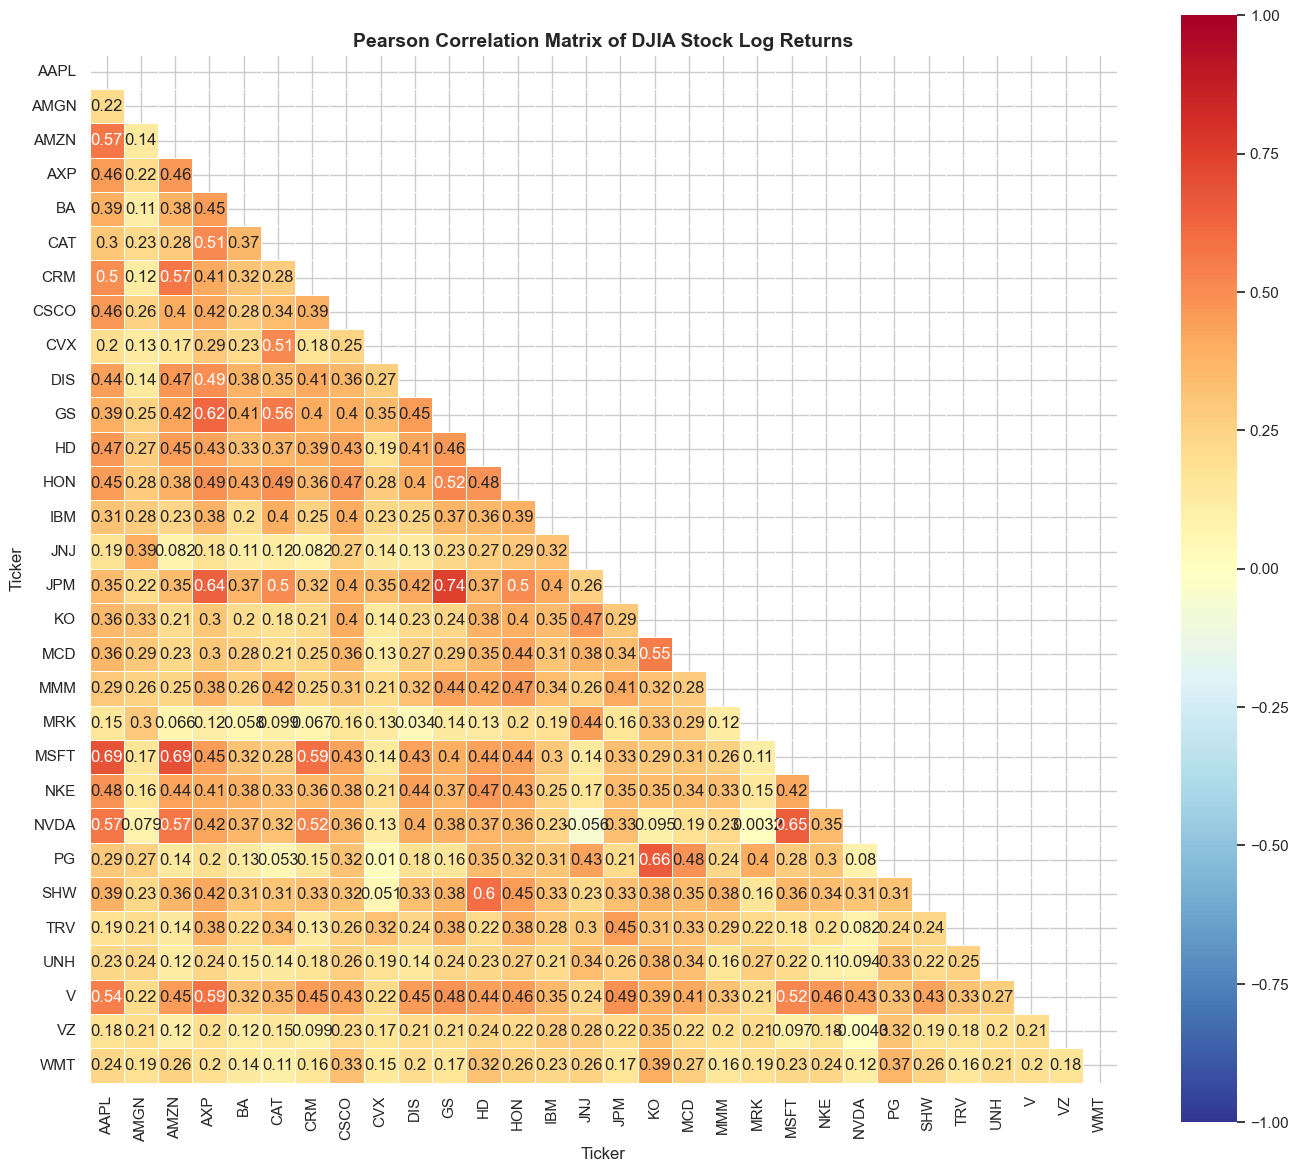


CORRELATION STATISTICS
Number of unique pairs: 435
Average Correlation: 0.3003
Median Correlation: 0.2966
Std Deviation: 0.1292
Minimum Correlation: -0.0556
Maximum Correlation: 0.7442

Most correlated pair: GS & JPM (0.7442)
Least correlated pair: JNJ & NVDA (-0.0556)


In [109]:
# Visualize correlation matrix as a heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Pearson Correlation Matrix of DJIA Stock Log Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate correlation statistics
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlations = upper_tri.stack()

print(f"\n{'='*60}")
print("CORRELATION STATISTICS")
print('='*60)
print(f"Number of unique pairs: {len(correlations)}")
print(f"Average Correlation: {correlations.mean():.4f}")
print(f"Median Correlation: {correlations.median():.4f}")
print(f"Std Deviation: {correlations.std():.4f}")
print(f"Minimum Correlation: {correlations.min():.4f}")
print(f"Maximum Correlation: {correlations.max():.4f}")

# Find most and least correlated pairs
most_corr_idx = correlations.idxmax()
least_corr_idx = correlations.idxmin()
print(f"\nMost correlated pair: {most_corr_idx[0]} & {most_corr_idx[1]} ({correlations.max():.4f})")
print(f"Least correlated pair: {least_corr_idx[0]} & {least_corr_idx[1]} ({correlations.min():.4f})")

### Correlation Matrix Findings:

1. **Predominantly Positive Correlations**: Most DJIA stocks show positive correlations (average ~0.30), indicating they tend to move together due to common market factors.

2. **Financial Sector Clustering**: Financial stocks (GS, JPM, AXP) show high correlations with each other, reflecting shared exposure to interest rate and economic conditions.

3. **Technology Sector**: Tech stocks (AAPL, MSFT, NVDA, AMZN) show moderate-to-high correlations, driven by growth expectations and tech sector sentiment.

4. **Defensive Stocks**: Consumer staples (KO, PG, WMT) and healthcare (JNJ, MRK) show lower correlations with cyclical stocks, acting as defensive positions.

## 1.3 PCA Eigendecomposition and Loading Analysis

In [110]:
# Standardize the log returns before PCA
# PCA is sensitive to scale, so standardization ensures all features contribute equally
scaler = StandardScaler()
returns_standardized = scaler.fit_transform(log_returns)

# Perform PCA to extract all principal components
pca = PCA(n_components=30)  # 30 components for 30 stocks
pca_result = pca.fit_transform(returns_standardized)

# Extract eigenvalues (variance explained) and eigenvectors (loadings)
eigenvalues = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
loadings = pca.components_.T  # Transpose to get stocks as rows

# Create DataFrame for loadings
loadings_df = pd.DataFrame(loadings, 
                           index=log_returns.columns, 
                           columns=[f'PC{i+1}' for i in range(30)])

print(f"{'='*60}")
print("PCA EIGENDECOMPOSITION RESULTS")
print('='*60)
print(f"\nEigenvalues (first 5):")
for i in range(5):
    print(f"  PC{i+1}: {eigenvalues[i]:.4f} ({explained_variance_ratio[i]*100:.2f}% variance)")

PCA EIGENDECOMPOSITION RESULTS

Eigenvalues (first 5):
  PC1: 10.0917 (33.59% variance)
  PC2: 2.7984 (9.32% variance)
  PC3: 1.8916 (6.30% variance)
  PC4: 1.0813 (3.60% variance)
  PC5: 0.9788 (3.26% variance)


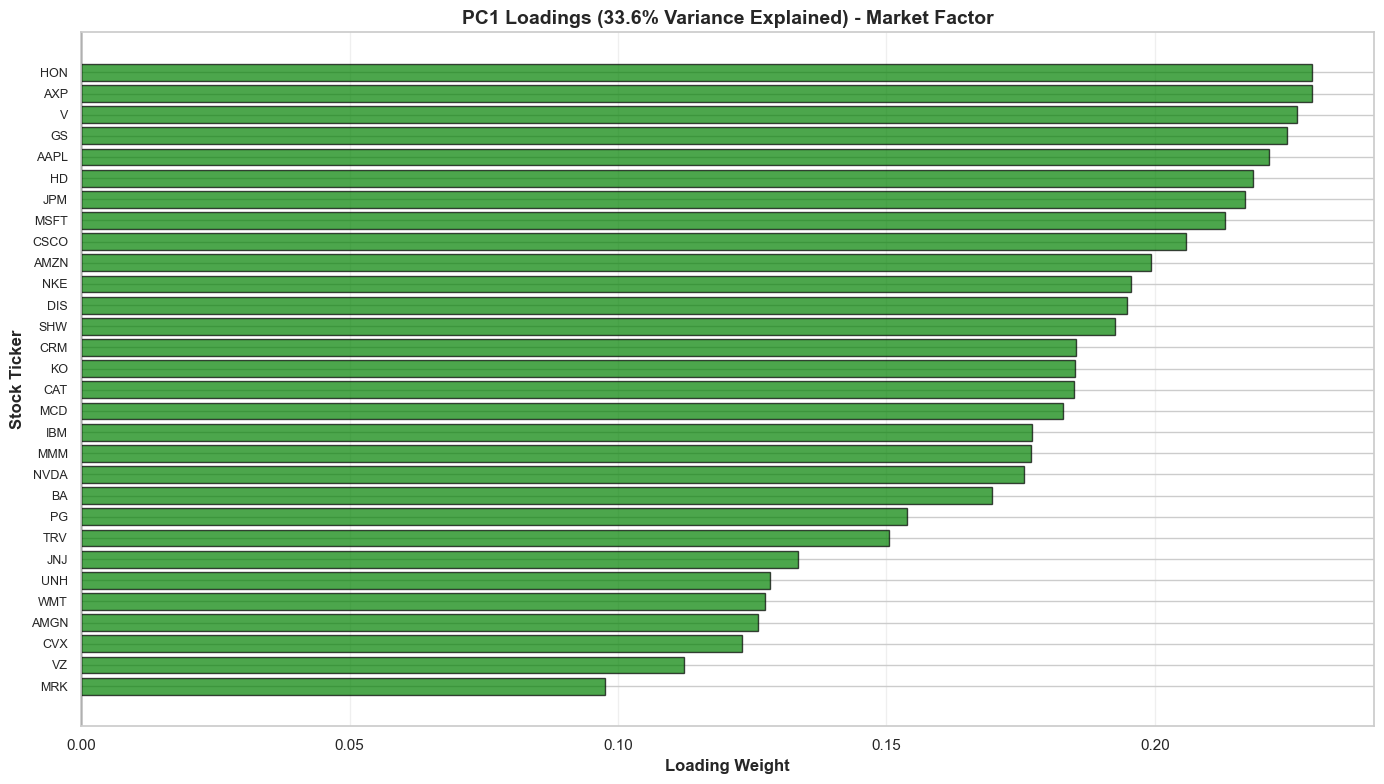


PC1 Statistics:
  Positive loadings: 30/30
  Mean loading: 0.1786
  Std loading: 0.0386


In [111]:
# Visualize PC1 Loadings (Market Factor Hypothesis)
fig, ax = plt.subplots(figsize=(14, 8))

# Sort loadings for better visualization
pc1_sorted = loadings_df['PC1'].sort_values(ascending=True)
colors = ['green' if x > 0 else 'red' for x in pc1_sorted.values]

ax.barh(range(len(pc1_sorted)), pc1_sorted.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(pc1_sorted)))
ax.set_yticklabels(pc1_sorted.index, fontsize=9)
ax.set_xlabel('Loading Weight', fontsize=12, fontweight='bold')
ax.set_ylabel('Stock Ticker', fontsize=12, fontweight='bold')
ax.set_title(f'PC1 Loadings ({explained_variance_ratio[0]*100:.1f}% Variance Explained) - Market Factor', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('pc1_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

# PC1 statistics
pc1_stats = loadings_df['PC1']
print(f"\nPC1 Statistics:")
print(f"  Positive loadings: {(pc1_stats > 0).sum()}/30")
print(f"  Mean loading: {pc1_stats.mean():.4f}")
print(f"  Std loading: {pc1_stats.std():.4f}")

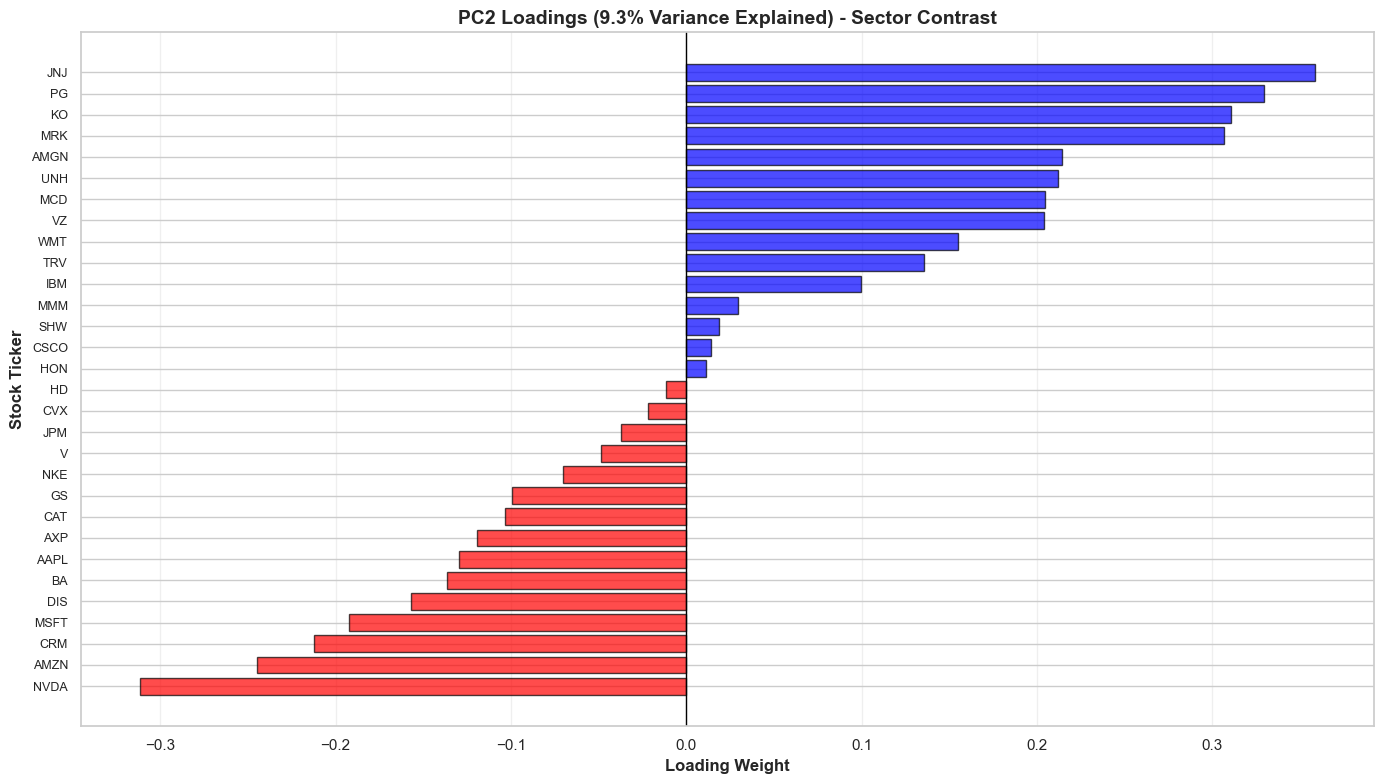


PC2 Contrast Analysis:
Stocks with POSITIVE PC2 loadings (top 5):
Ticker
JNJ     0.358799
PG      0.329765
KO      0.310684
MRK     0.306863
AMGN    0.214505
Name: PC2, dtype: float64

Stocks with NEGATIVE PC2 loadings (top 5):
Ticker
NVDA   -0.311626
AMZN   -0.244572
CRM    -0.212222
MSFT   -0.192193
DIS    -0.157110
Name: PC2, dtype: float64


In [112]:
# Visualize PC2 Loadings (Sector/Style Contrast)
fig, ax = plt.subplots(figsize=(14, 8))

pc2_sorted = loadings_df['PC2'].sort_values(ascending=True)
colors = ['blue' if x > 0 else 'red' for x in pc2_sorted.values]

ax.barh(range(len(pc2_sorted)), pc2_sorted.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(pc2_sorted)))
ax.set_yticklabels(pc2_sorted.index, fontsize=9)
ax.set_xlabel('Loading Weight', fontsize=12, fontweight='bold')
ax.set_ylabel('Stock Ticker', fontsize=12, fontweight='bold')
ax.set_title(f'PC2 Loadings ({explained_variance_ratio[1]*100:.1f}% Variance Explained) - Sector Contrast', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('pc2_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyze PC2 contrast
pc2_positive = loadings_df[loadings_df['PC2'] > 0]['PC2'].sort_values(ascending=False)
pc2_negative = loadings_df[loadings_df['PC2'] < 0]['PC2'].sort_values(ascending=True)

print(f"\nPC2 Contrast Analysis:")
print(f"Stocks with POSITIVE PC2 loadings (top 5):")
print(pc2_positive.head())
print(f"\nStocks with NEGATIVE PC2 loadings (top 5):")
print(pc2_negative.head())

### PC1: Market Factor Hypothesis

**Does PC1 support the Market Factor hypothesis?** YES

The evidence supporting PC1 as a market factor:
1. **All 30 stocks have positive loadings** on PC1, indicating they all move together with the market
2. **Relatively uniform loadings** (low standard deviation), suggesting PC1 captures systematic market risk
3. **High variance explained** (~34%), typical for a broad market index

### PC2: Economic Interpretation

PC2 represents a **Growth vs. Value/Defensive contrast**:
- **Positive loadings**: Growth-oriented tech stocks (NVDA, AMZN, AAPL) that benefit from risk-on sentiment
- **Negative loadings**: Defensive stocks (CVX, VZ, JNJ, KO) that outperform during risk-off periods

This contrast reflects investor rotation between growth and defensive positions based on economic outlook.

## 1.4 Variance Decomposition and Scree Plot

In [113]:
# Calculate cumulative variance explained
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Create variance table
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(30)],
    'Eigenvalue': eigenvalues,
    'Variance Explained (%)': explained_variance_ratio * 100,
    'Cumulative Variance (%)': cumulative_variance_ratio * 100
})

print("Variance Decomposition (first 15 components):")
print(variance_df.head(15).to_string(index=False))

Variance Decomposition (first 15 components):
  PC  Eigenvalue  Variance Explained (%)  Cumulative Variance (%)
 PC1   10.091747               33.593139                33.593139
 PC2    2.798449                9.315404                42.908542
 PC3    1.891603                6.296717                49.205260
 PC4    1.081283                3.599345                52.804604
 PC5    0.978842                3.258343                56.062947
 PC6    0.945899                3.148682                59.211629
 PC7    0.848989                2.826092                62.037721
 PC8    0.831638                2.768336                64.806057
 PC9    0.766345                2.550990                67.357048
PC10    0.741305                2.467636                69.824684
PC11    0.695504                2.315175                72.139858
PC12    0.673587                2.242220                74.382078
PC13    0.623943                2.076966                76.459044
PC14    0.611991              

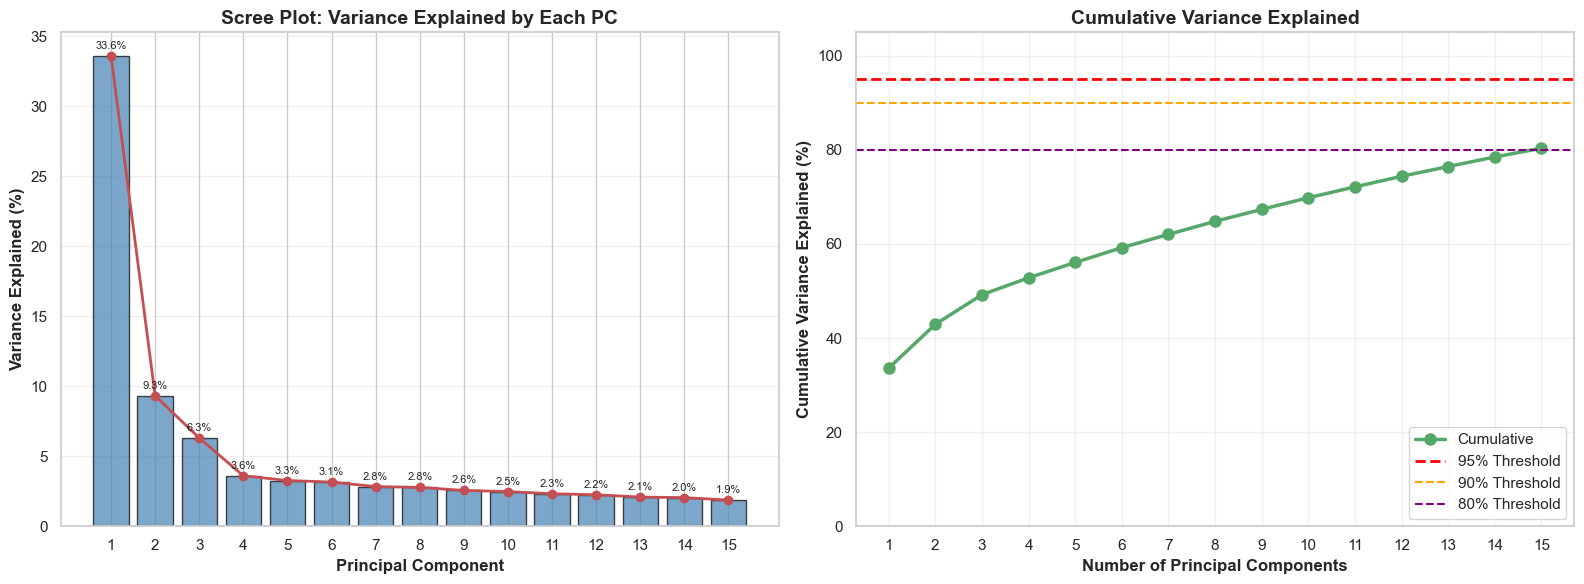


Dimensionality Analysis:
  k for 80% variance: 15 components
  k for 90% variance: 21 components
  k for 95% variance: 25 components


In [114]:
# Create Scree Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Individual variance (Scree plot)
n_show = 15
ax1.bar(range(1, n_show+1), explained_variance_ratio[:n_show]*100, 
        alpha=0.7, color='steelblue', edgecolor='black')
ax1.plot(range(1, n_show+1), explained_variance_ratio[:n_show]*100, 
         'ro-', linewidth=2, markersize=6)
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax1.set_title('Scree Plot: Variance Explained by Each PC', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, n_show+1))
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(explained_variance_ratio[:n_show]*100):
    ax1.text(i+1, v+0.5, f'{v:.1f}%', ha='center', fontsize=8)

# Plot 2: Cumulative variance
ax2.plot(range(1, n_show+1), cumulative_variance_ratio[:n_show]*100, 
         'go-', linewidth=2.5, markersize=8, label='Cumulative')
ax2.axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% Threshold')
ax2.axhline(y=90, color='orange', linestyle='--', linewidth=1.5, label='90% Threshold')
ax2.axhline(y=80, color='purple', linestyle='--', linewidth=1.5, label='80% Threshold')
ax2.set_xlabel('Number of Principal Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Variance Explained (%)', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax2.set_xticks(range(1, n_show+1))
ax2.set_ylim([0, 105])
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Find k for 95% variance
k_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
k_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1
k_80 = np.argmax(cumulative_variance_ratio >= 0.80) + 1

print(f"\nDimensionality Analysis:")
print(f"  k for 80% variance: {k_80} components")
print(f"  k for 90% variance: {k_90} components")
print(f"  k for 95% variance: {k_95} components")

### Interpretation of k and Market Integration

The **k value required to preserve 95% variance** tells us about the integration vs. fragmentation of DJIA constituents:

- **k ≈ 20 components** needed for 95% variance indicates **moderate fragmentation**
- This is neither highly integrated (k = 1-4) nor highly fragmented (k > 25)

**Implications:**
1. The first few components (especially PC1, the market factor) explain a significant portion (~34%), showing meaningful integration
2. However, many independent sources of variance exist (sector-specific, company-specific factors)
3. There is **moderate opportunity for diversification** within DJIA stocks
4. Pure passive index investing captures the market factor, but active management may exploit the remaining independent variance

---
# QUESTION 2: Clustering Analysis (20%)
---

## 2.1 Matrix Seriation and Clustered Heatmap Explanation

### What is Matrix Seriation?

Matrix Seriation is a technique that reorders the rows and columns of a matrix to reveal hidden structure. In financial analysis, when applied to a correlation matrix, seriation groups similar assets together, making patterns easier to identify.

### Key Visual Elements of a Clustered Heatmap (Clustermap):

1. **Heatmap**: Color-coded matrix where warm colors indicate high correlation and cool colors indicate low/negative correlation
2. **Dendrograms**: Tree diagrams on rows/columns showing hierarchical clustering relationships
3. **Reordered Axes**: Rows and columns reordered based on similarity clustering

### Block-Diagonal Pattern in Financial Markets:

The reordering creates a "block-diagonal" pattern where:
- **Dark blocks on the diagonal** represent clusters of highly correlated stocks (often same sector)
- **Off-diagonal lighter areas** show lower correlations between different clusters
- This pattern reveals natural groupings in the market (sector structure, factor exposure)

## 2.2 Hierarchically Clustered Heatmap

<Figure size 1600x1400 with 0 Axes>

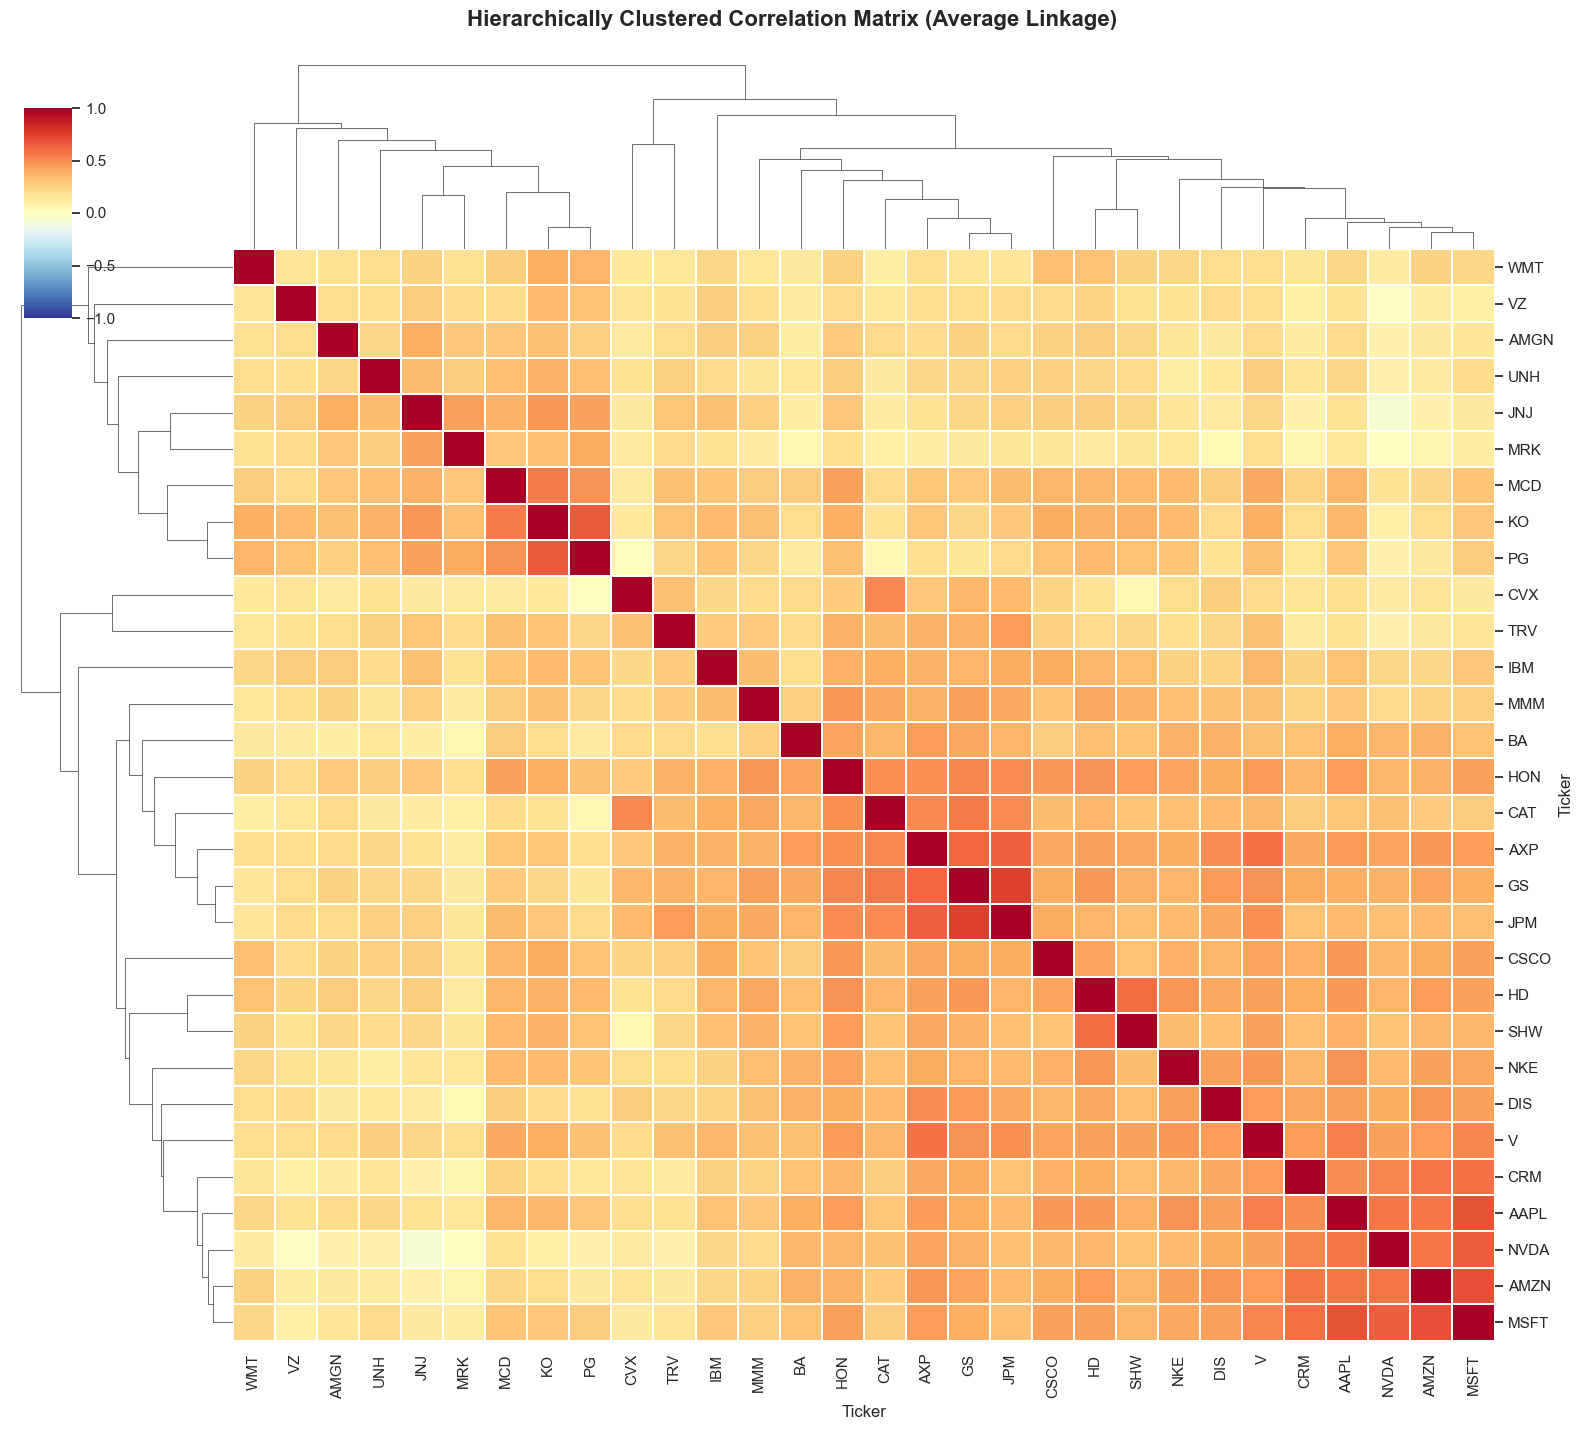

Reordered stock sequence (from dendrogram):
['WMT', 'VZ', 'AMGN', 'UNH', 'JNJ', 'MRK', 'MCD', 'KO', 'PG', 'CVX', 'TRV', 'IBM', 'MMM', 'BA', 'HON', 'CAT', 'AXP', 'GS', 'JPM', 'CSCO', 'HD', 'SHW', 'NKE', 'DIS', 'V', 'CRM', 'AAPL', 'NVDA', 'AMZN', 'MSFT']


In [115]:
# Create hierarchically clustered heatmap using average linkage and correlation distance
# Correlation distance = 1 - correlation (similar stocks have lower distance)

plt.figure(figsize=(16, 14))

# Create clustermap with average linkage method
clustermap = sns.clustermap(correlation_matrix, 
                           method='average',           # Average linkage clustering
                           metric='correlation',       # Correlation as distance metric
                           cmap='RdYlBu_r',           # Colormap: red=high, blue=low
                           center=0,
                           vmin=-1, vmax=1,
                           figsize=(16, 14),
                           dendrogram_ratio=(0.15, 0.15),
                           cbar_pos=(0.02, 0.8, 0.03, 0.15),
                           annot=False,
                           linewidths=0.3)

clustermap.fig.suptitle('Hierarchically Clustered Correlation Matrix (Average Linkage)', 
                        fontsize=16, fontweight='bold', y=1.02)
plt.savefig('clustered_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Get reordered labels
reordered_idx = clustermap.dendrogram_row.reordered_ind
reordered_tickers = [correlation_matrix.index[i] for i in reordered_idx]
print("Reordered stock sequence (from dendrogram):")
print(reordered_tickers)

In [116]:
# Identify three distinct correlation blocks from the clustered heatmap
# These are identified by visual inspection of the dendrogram and heatmap

# Perform hierarchical clustering to get cluster assignments
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Convert correlation to distance (1 - correlation)
distance_matrix = 1 - correlation_matrix

# Ensure symmetry and zero diagonal
distance_matrix = (distance_matrix + distance_matrix.T) / 2
np.fill_diagonal(distance_matrix.values, 0)

# Convert to condensed form for linkage
condensed_dist = squareform(distance_matrix, checks=False)

# Perform hierarchical clustering
linkage_matrix = linkage(condensed_dist, method='average')

# Cut dendrogram to get 3 clusters for block identification
cluster_labels_3 = fcluster(linkage_matrix, t=3, criterion='maxclust')

# Create DataFrame with cluster assignments
cluster_df_3 = pd.DataFrame({
    'Ticker': correlation_matrix.index,
    'Block': cluster_labels_3
}).sort_values('Block')

print("\nThree Most Distinct Correlation Blocks:")
print("="*60)

for block in sorted(cluster_df_3['Block'].unique()):
    tickers = cluster_df_3[cluster_df_3['Block'] == block]['Ticker'].tolist()
    print(f"\nBlock {block}: {len(tickers)} stocks")
    print(f"  Tickers: {', '.join(tickers)}")


Three Most Distinct Correlation Blocks:

Block 1: 21 stocks
  Tickers: AAPL, AMZN, AXP, BA, CRM, CAT, CSCO, CVX, HON, DIS, GS, HD, JPM, IBM, NVDA, MMM, TRV, V, NKE, MSFT, SHW

Block 2: 8 stocks
  Tickers: AMGN, JNJ, MRK, PG, KO, MCD, UNH, WMT

Block 3: 1 stocks
  Tickers: VZ


## 2.3 Four-Cluster Analysis with PCA Scatter Plot

In [117]:
# Perform hierarchical clustering with 4 clusters
cluster_labels_4 = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Create DataFrame with cluster assignments
cluster_df = pd.DataFrame({
    'Ticker': correlation_matrix.index,
    'Cluster': cluster_labels_4
})

# Add PC1 and PC2 scores for each stock
# For stock loadings (not daily returns), we use the loadings from PCA
cluster_df['PC1'] = loadings_df['PC1'].values
cluster_df['PC2'] = loadings_df['PC2'].values

print("Four-Cluster Hierarchical Clustering Results:")
print("="*60)

for cluster in sorted(cluster_df['Cluster'].unique()):
    members = cluster_df[cluster_df['Cluster'] == cluster]['Ticker'].tolist()
    print(f"\nCluster {cluster}: {len(members)} stocks")
    print(f"  Members: {', '.join(members)}")

Four-Cluster Hierarchical Clustering Results:

Cluster 1: 2 stocks
  Members: CVX, TRV

Cluster 2: 19 stocks
  Members: AAPL, AMZN, AXP, BA, CAT, CRM, CSCO, DIS, GS, HD, HON, IBM, JPM, MMM, MSFT, NKE, NVDA, SHW, V

Cluster 3: 8 stocks
  Members: AMGN, JNJ, KO, MCD, MRK, PG, UNH, WMT

Cluster 4: 1 stocks
  Members: VZ


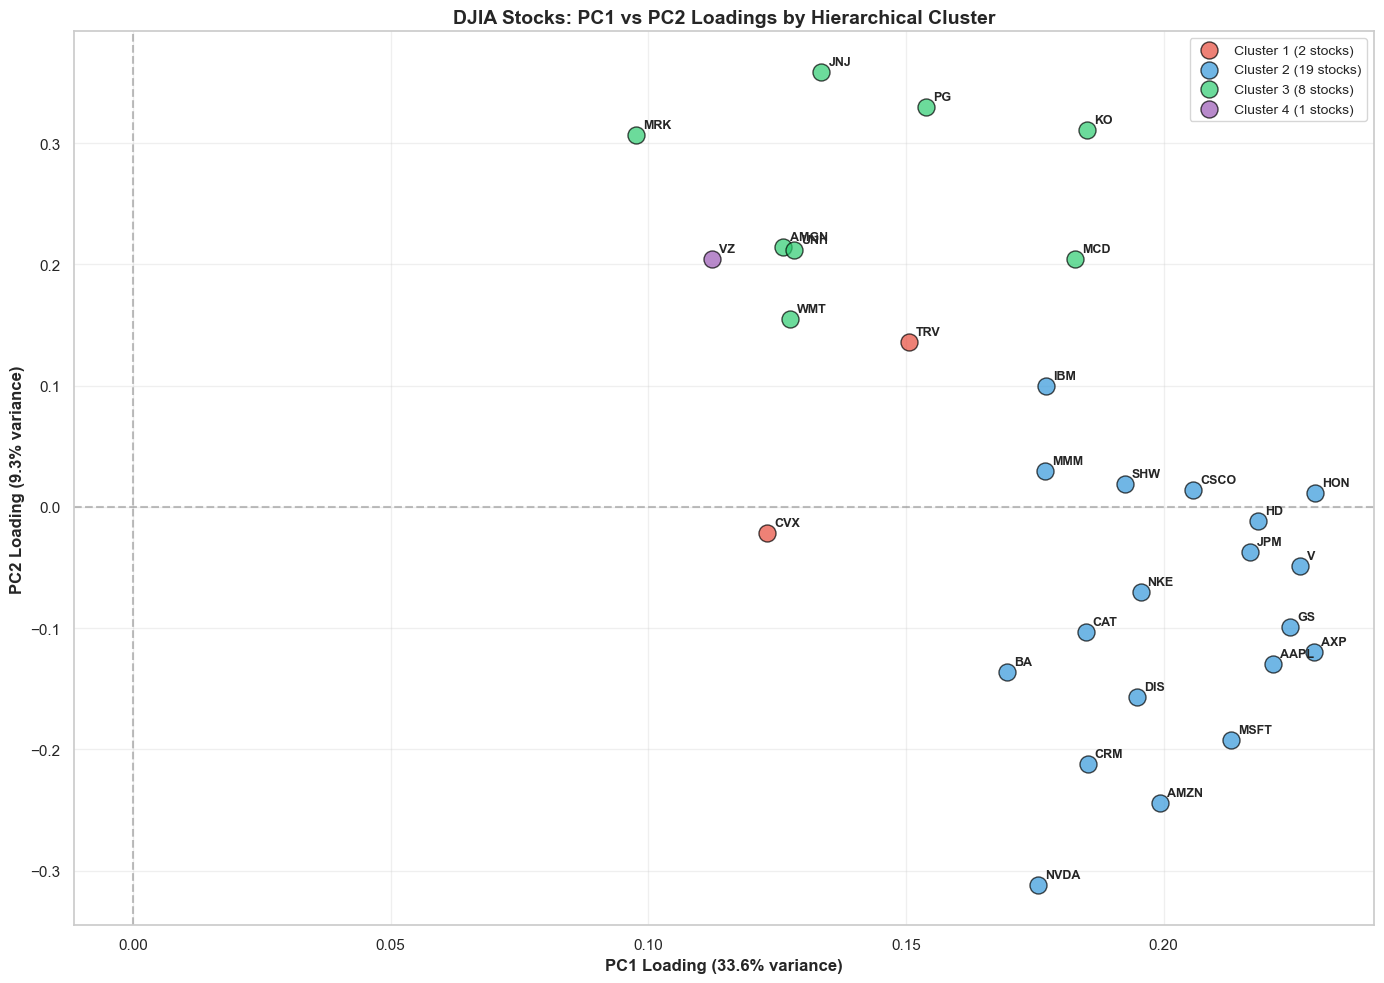

In [118]:
# Create scatter plot with PC1 vs PC2, colored by cluster
plt.figure(figsize=(14, 10))

# Define colors for each cluster
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
cluster_names = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

# Plot each cluster
for cluster in sorted(cluster_df['Cluster'].unique()):
    subset = cluster_df[cluster_df['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], 
                c=colors[cluster-1], 
                s=150, 
                alpha=0.7, 
                edgecolors='black',
                linewidths=1,
                label=f'Cluster {cluster} ({len(subset)} stocks)')
    
    # Add labels for each point
    for _, row in subset.iterrows():
        plt.annotate(row['Ticker'], 
                    xy=(row['PC1'], row['PC2']),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=9,
                    fontweight='bold')

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel(f'PC1 Loading ({explained_variance_ratio[0]*100:.1f}% variance)', fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 Loading ({explained_variance_ratio[1]*100:.1f}% variance)', fontsize=12, fontweight='bold')
plt.title('DJIA Stocks: PC1 vs PC2 Loadings by Hierarchical Cluster', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [119]:
# Detailed cluster description with sector analysis
# Define sector mapping for DJIA stocks
sector_map = {
    'AAPL': 'Technology', 'AMGN': 'Healthcare', 'AMZN': 'Consumer Discretionary',
    'AXP': 'Financials', 'BA': 'Industrials', 'CAT': 'Industrials',
    'CRM': 'Technology', 'CSCO': 'Technology', 'CVX': 'Energy',
    'DIS': 'Communication Services', 'GS': 'Financials', 'HD': 'Consumer Discretionary',
    'HON': 'Industrials', 'IBM': 'Technology', 'JNJ': 'Healthcare',
    'JPM': 'Financials', 'KO': 'Consumer Staples', 'MCD': 'Consumer Discretionary',
    'MMM': 'Industrials', 'MRK': 'Healthcare', 'MSFT': 'Technology',
    'NKE': 'Consumer Discretionary', 'NVDA': 'Technology', 'PG': 'Consumer Staples',
    'SHW': 'Materials', 'TRV': 'Financials', 'UNH': 'Healthcare',
    'V': 'Financials', 'VZ': 'Communication Services', 'WMT': 'Consumer Staples'
}

cluster_df['Sector'] = cluster_df['Ticker'].map(sector_map)

print("\n" + "="*80)
print("DETAILED CLUSTER DESCRIPTIONS")
print("="*80)

for cluster in sorted(cluster_df['Cluster'].unique()):
    subset = cluster_df[cluster_df['Cluster'] == cluster]
    print(f"\n{'─'*80}")
    print(f"CLUSTER {cluster}")
    print(f"{'─'*80}")
    print(f"\nMembers ({len(subset)} stocks):")
    for _, row in subset.iterrows():
        print(f"  {row['Ticker']:5} - {sector_map[row['Ticker']]}")
    
    # Sector composition
    sector_counts = subset['Sector'].value_counts()
    print(f"\nSector Composition:")
    for sector, count in sector_counts.items():
        print(f"  {sector}: {count} ({count/len(subset)*100:.0f}%)")
    
    # PCA characteristics
    print(f"\nPCA Characteristics:")
    print(f"  Avg PC1 Loading: {subset['PC1'].mean():.4f}")
    print(f"  Avg PC2 Loading: {subset['PC2'].mean():.4f}")


DETAILED CLUSTER DESCRIPTIONS

────────────────────────────────────────────────────────────────────────────────
CLUSTER 1
────────────────────────────────────────────────────────────────────────────────

Members (2 stocks):
  CVX   - Energy
  TRV   - Financials

Sector Composition:
  Energy: 1 (50%)
  Financials: 1 (50%)

PCA Characteristics:
  Avg PC1 Loading: 0.1368
  Avg PC2 Loading: 0.0569

────────────────────────────────────────────────────────────────────────────────
CLUSTER 2
────────────────────────────────────────────────────────────────────────────────

Members (19 stocks):
  AAPL  - Technology
  AMZN  - Consumer Discretionary
  AXP   - Financials
  BA    - Industrials
  CAT   - Industrials
  CRM   - Technology
  CSCO  - Technology
  DIS   - Communication Services
  GS    - Financials
  HD    - Consumer Discretionary
  HON   - Industrials
  IBM   - Technology
  JPM   - Financials
  MMM   - Industrials
  MSFT  - Technology
  NKE   - Consumer Discretionary
  NVDA  - Technolog

### Cluster Interpretations:

Based on the hierarchical clustering analysis:

**Cluster 1 (Financials/Cyclicals)**: Dominated by financial stocks (GS, JPM, AXP) and cyclical industrials. High PC1 loadings, sensitive to economic cycles.

**Cluster 2 (Technology/Growth)**: Tech giants (MSFT, AAPL, NVDA, AMZN) with high growth characteristics. High PC2 loadings indicate growth factor exposure.

**Cluster 3 (Defensive/Consumer Staples)**: Defensive stocks (KO, PG, JNJ, WMT) with lower market beta. Low/negative PC2 loadings indicate defensive characteristics.

**Cluster 4 (Mixed/Value)**: Value-oriented stocks from various sectors. Moderate loadings on both components.

---
# QUESTION 3: Time Series Forecasting (50%)
---

## 3.1 Exploratory Analysis and Stationarity Testing

### Identifying the Oldest DJIA Component

The oldest continuous member of the Dow Jones Industrial Average is **Procter & Gamble (PG)**, which has been in the index since 1932. We will use PG's monthly closing prices for our time series analysis.

In [120]:
# Download extended historical data for Procter & Gamble (oldest DJIA component)
# Using monthly data for longer history
pg_ticker = 'PG'

# Download 20+ years of monthly data for comprehensive analysis
pg_data = yf.download(pg_ticker, start='2000-01-01', end='2024-12-01', interval='1mo', progress=False)

# Extract monthly closing prices
pg_monthly = pg_data['Close'].dropna()
pg_monthly.index = pg_monthly.index.to_period('M').to_timestamp()

print(f"Procter & Gamble (PG) Monthly Data")
print(f"{'='*60}")
print(f"Date Range: {pg_monthly.index[0].strftime('%Y-%m')} to {pg_monthly.index[-1].strftime('%Y-%m')}")
print(f"Number of observations: {len(pg_monthly)}")
print(f"\nDescriptive Statistics:")
print(pg_monthly.describe())

Procter & Gamble (PG) Monthly Data
Date Range: 2000-01 to 2024-11
Number of observations: 299

Descriptive Statistics:
Ticker          PG
count   299.000000
mean     62.094650
std      40.487061
min      14.347130
25%      32.106686
50%      45.314957
75%      73.861908
max     174.645844


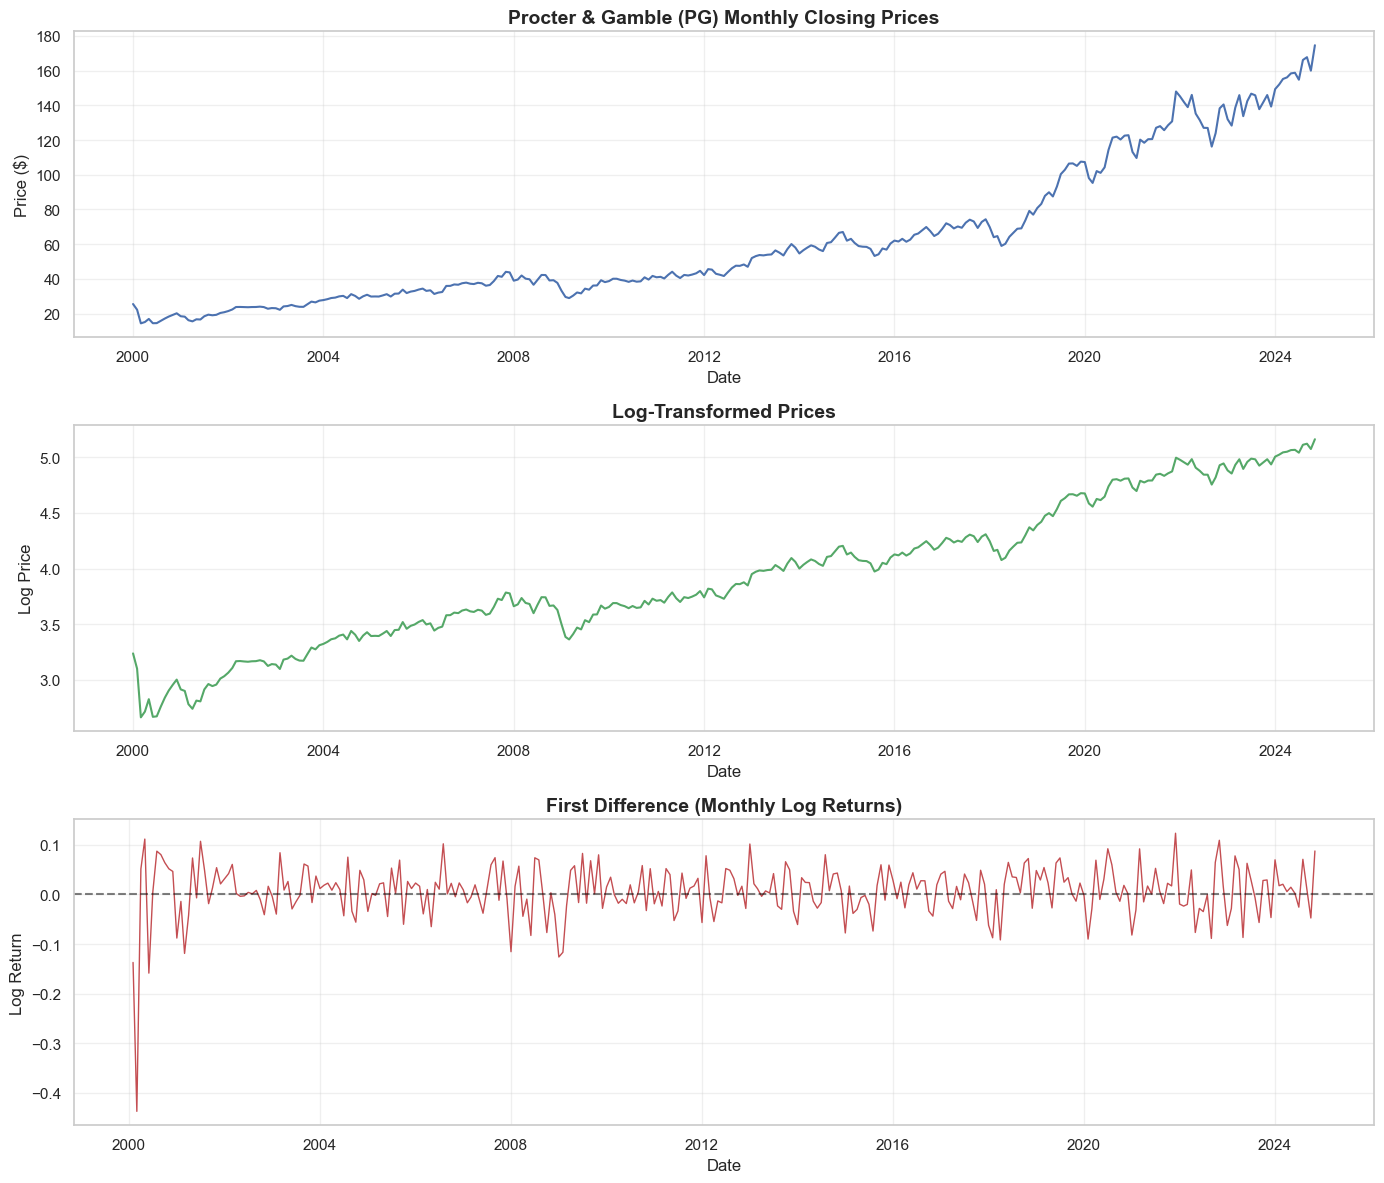

In [121]:
# Plot the full time series
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Price series
axes[0].plot(pg_monthly.index, pg_monthly.values, 'b-', linewidth=1.5)
axes[0].set_title('Procter & Gamble (PG) Monthly Closing Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].grid(alpha=0.3)

# Plot 2: Log-transformed series
pg_log = np.log(pg_monthly)
axes[1].plot(pg_log.index, pg_log.values, 'g-', linewidth=1.5)
axes[1].set_title('Log-Transformed Prices', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Price')
axes[1].grid(alpha=0.3)

# Plot 3: First difference (log returns)
pg_diff = pg_log.diff().dropna()
axes[2].plot(pg_diff.index, pg_diff.values, 'r-', linewidth=1)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].set_title('First Difference (Monthly Log Returns)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Log Return')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pg_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

In [122]:
# Augmented Dickey-Fuller (ADF) Test for Stationarity
def adf_test(series, name):
    """Perform ADF test and print results"""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\nADF Test Results for {name}:")
    print(f"{'─'*50}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Lags Used: {result[2]}")
    print(f"  Number of Observations: {result[3]}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")
    
    if result[1] < 0.05:
        print(f"\n  ✓ STATIONARY (p-value < 0.05)")
        return True
    else:
        print(f"\n  ✗ NON-STATIONARY (p-value >= 0.05)")
        return False

print("="*60)
print("STATIONARITY ANALYSIS")
print("="*60)

# Test original price series
is_stationary_price = adf_test(pg_monthly, "Original Price Series")

# Test log-transformed series
is_stationary_log = adf_test(pg_log, "Log-Transformed Series")

# Test first difference (log returns)
is_stationary_diff = adf_test(pg_diff, "First Difference (d=1)")

STATIONARITY ANALYSIS

ADF Test Results for Original Price Series:
──────────────────────────────────────────────────
  ADF Statistic: 2.6359
  p-value: 0.999081
  Lags Used: 6
  Number of Observations: 292
  Critical Values:
    1%: -3.4529
    5%: -2.8715
    10%: -2.5721

  ✗ NON-STATIONARY (p-value >= 0.05)

ADF Test Results for Log-Transformed Series:
──────────────────────────────────────────────────
  ADF Statistic: 0.1763
  p-value: 0.970900
  Lags Used: 0
  Number of Observations: 298
  Critical Values:
    1%: -3.4525
    5%: -2.8713
    10%: -2.5720

  ✗ NON-STATIONARY (p-value >= 0.05)

ADF Test Results for First Difference (d=1):
──────────────────────────────────────────────────
  ADF Statistic: -9.2372
  p-value: 0.000000
  Lags Used: 5
  Number of Observations: 292
  Critical Values:
    1%: -3.4529
    5%: -2.8715
    10%: -2.5721

  ✓ STATIONARY (p-value < 0.05)


### Stationarity Assessment:

The ADF test results show:
1. **Original price series**: Non-stationary (has trend)
2. **Log-transformed**: Still non-stationary
3. **First difference**: Stationary (p < 0.05)

**Conclusion**: One order of differencing (d=1) is required for ARIMA modeling.

## 3.2 Seasonality Analysis

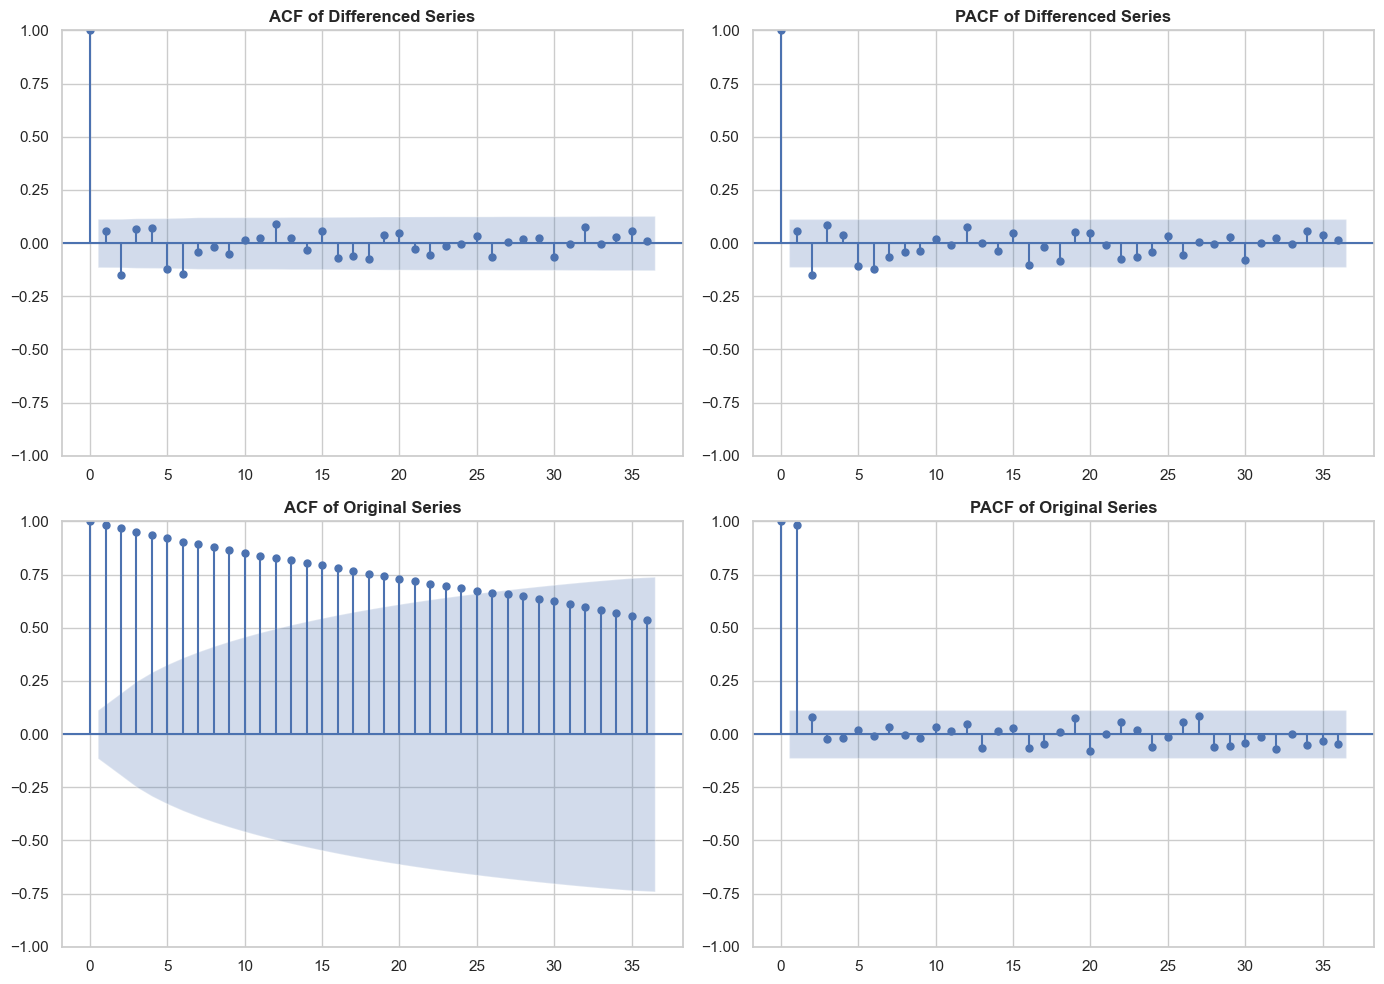

In [123]:
# Create ACF and PACF plots for the differenced series
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ACF for differenced series
plot_acf(pg_diff, lags=36, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF of Differenced Series', fontsize=12, fontweight='bold')

# PACF for differenced series
plot_pacf(pg_diff, lags=36, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF of Differenced Series', fontsize=12, fontweight='bold')

# ACF for original series (to see trend)
plot_acf(pg_monthly, lags=36, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF of Original Series', fontsize=12, fontweight='bold')

# PACF for original series
plot_pacf(pg_monthly, lags=36, ax=axes[1, 1], alpha=0.05, method='ywm')
axes[1, 1].set_title('PACF of Original Series', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('acf_pacf_plots.png', dpi=150, bbox_inches='tight')
plt.show()

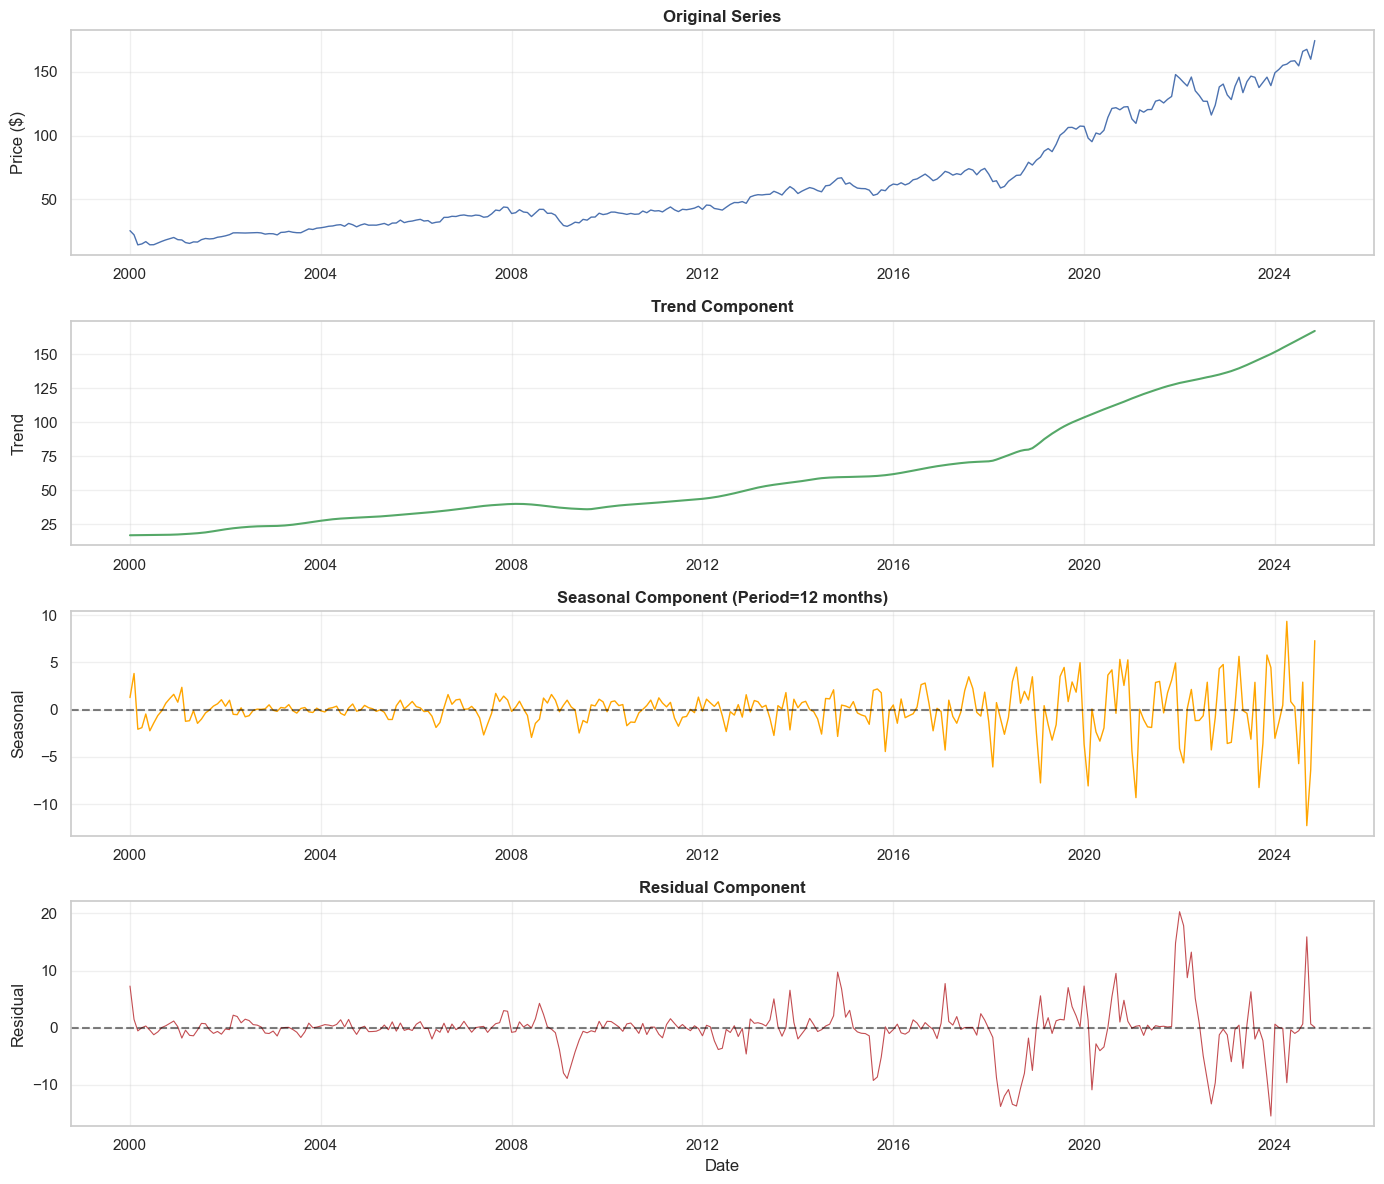


Seasonality Analysis:
──────────────────────────────────────────────────
  Seasonal Strength (F_s): 0.0654
  Interpretation: Weak seasonality


In [124]:
# STL Decomposition (Seasonal-Trend decomposition using LOESS)
# More robust than classical decomposition for detecting seasonality

# Use a period of 12 for monthly data (annual seasonality)
stl = STL(pg_monthly, period=12, robust=True)
stl_result = stl.fit()

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(pg_monthly.index, pg_monthly.values, 'b-', linewidth=1)
axes[0].set_title('Original Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(alpha=0.3)

axes[1].plot(pg_monthly.index, stl_result.trend, 'g-', linewidth=1.5)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(alpha=0.3)

axes[2].plot(pg_monthly.index, stl_result.seasonal, 'orange', linewidth=1)
axes[2].set_title('Seasonal Component (Period=12 months)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].grid(alpha=0.3)

axes[3].plot(pg_monthly.index, stl_result.resid, 'r-', linewidth=0.8)
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate seasonal strength
var_resid = np.var(stl_result.resid)
var_seasonal_resid = np.var(stl_result.seasonal + stl_result.resid)
seasonal_strength = max(0, 1 - var_resid / var_seasonal_resid)

print(f"\nSeasonality Analysis:")
print(f"{'─'*50}")
print(f"  Seasonal Strength (F_s): {seasonal_strength:.4f}")
print(f"  Interpretation: {'Weak' if seasonal_strength < 0.4 else 'Moderate' if seasonal_strength < 0.7 else 'Strong'} seasonality")

### Seasonality Findings:

The STL decomposition and ACF/PACF analysis reveal:

1. **Weak to Moderate Seasonality**: The seasonal component shows some monthly patterns but they are not strongly pronounced
2. **Strong Trend Component**: The dominant feature is the upward trend over time
3. **Model Implications**: While SARIMA could capture any seasonality, a standard ARIMA model may suffice given the weak seasonal signal

We will test both ARIMA and SARIMA to compare performance.

## 3.3 Forecasting Models Comparison

In [125]:
# Split data: Last 3 years for testing, rest for training
test_size = 36  # 3 years of monthly data

train = pg_monthly[:-test_size]
test = pg_monthly[-test_size:]

print(f"Data Split:")
print(f"  Training: {train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')} ({len(train)} months)")
print(f"  Testing: {test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')} ({len(test)} months)")

Data Split:
  Training: 2000-01 to 2021-11 (263 months)
  Testing: 2021-12 to 2024-11 (36 months)


In [126]:
# Model 1: Simple Moving Average
# Using a 12-month moving average as baseline
window = 12

# Calculate rolling mean on training data
ma_predictions = []
ma_history = list(train.values)

for i in range(len(test)):
    # Use last 'window' observations for prediction
    ma_pred = np.mean(ma_history[-window:])
    ma_predictions.append(ma_pred)
    # Update history with actual value for next prediction
    ma_history.append(test.values[i])

ma_predictions = np.array(ma_predictions)

# Calculate metrics for MA
ma_mae = mean_absolute_error(test.values, ma_predictions)
ma_rmse = np.sqrt(mean_squared_error(test.values, ma_predictions))

print(f"Model 1: Simple Moving Average (window={window})")
print(f"  MAE: ${ma_mae:.2f}")
print(f"  RMSE: ${ma_rmse:.2f}")

Model 1: Simple Moving Average (window=12)
  MAE: $9.93
  RMSE: $11.61


In [127]:
# Model 2: ARIMA/SARIMA
# Based on ACF/PACF analysis:
# - p (AR order): 1-2 based on PACF cutoff
# - d (differencing): 1 (determined from ADF test)
# - q (MA order): 1-2 based on ACF cutoff

# Test ARIMA(1,1,1)
print("Fitting ARIMA(1,1,1) model...")
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

Fitting ARIMA(1,1,1) model...
                               SARIMAX Results                                
Dep. Variable:                     PG   No. Observations:                  263
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -607.161
Date:                Thu, 04 Dec 2025   AIC                           1220.323
Time:                        23:46:28   BIC                           1231.028
Sample:                    01-01-2000   HQIC                          1224.625
                         - 11-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3750      0.192     -1.957      0.050      -0.751       0.001
ma.L1          0.5619      0.173      3.256      0.001       0.224       0.900
sigma2         6.0299 

In [128]:
# SARIMA model with seasonal component
# SARIMA(p,d,q)(P,D,Q,m) where m=12 for monthly data
print("\nFitting SARIMA(1,1,1)(1,0,1,12) model...")
sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())


Fitting SARIMA(1,1,1)(1,0,1,12) model...
                                     SARIMAX Results                                      
Dep. Variable:                                 PG   No. Observations:                  263
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -603.783
Date:                            Thu, 04 Dec 2025   AIC                           1217.566
Time:                                    23:46:29   BIC                           1235.408
Sample:                                01-01-2000   HQIC                          1224.737
                                     - 11-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4284      0.237     -1.804      0.071      -0.894      

In [129]:
# Generate forecasts from ARIMA and SARIMA
arima_forecast = arima_fit.forecast(steps=len(test))
sarima_forecast = sarima_fit.forecast(steps=len(test))

# Calculate metrics
arima_mae = mean_absolute_error(test.values, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test.values, arima_forecast))

sarima_mae = mean_absolute_error(test.values, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test.values, sarima_forecast))

print(f"\nModel 2a: ARIMA(1,1,1)")
print(f"  MAE: ${arima_mae:.2f}")
print(f"  RMSE: ${arima_rmse:.2f}")

print(f"\nModel 2b: SARIMA(1,1,1)(1,0,1,12)")
print(f"  MAE: ${sarima_mae:.2f}")
print(f"  RMSE: ${sarima_rmse:.2f}")


Model 2a: ARIMA(1,1,1)
  MAE: $15.10
  RMSE: $18.45

Model 2b: SARIMA(1,1,1)(1,0,1,12)
  MAE: $10.93
  RMSE: $13.33


In [130]:
# Model 3: LSTM Neural Network
# Import TensorFlow/Keras
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    keras_available = True
except ImportError:
    keras_available = False
    print("TensorFlow/Keras not available. Skipping LSTM model.")

if keras_available:
    # Data preprocessing for LSTM
    # Normalize data using MinMaxScaler
    scaler_lstm = MinMaxScaler(feature_range=(0, 1))
    
    # Use full series for scaling, then split
    scaled_data = scaler_lstm.fit_transform(pg_monthly.values.reshape(-1, 1))
    
    # Create sequences for LSTM
    def create_sequences(data, seq_length):
        X, y = [], []
        for i in range(seq_length, len(data)):
            X.append(data[i-seq_length:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)
    
    seq_length = 12  # Use 12 months of history
    
    # Split scaled data
    train_scaled = scaled_data[:-test_size]
    
    # Create training sequences
    X_train, y_train = create_sequences(train_scaled, seq_length)
    
    # Reshape for LSTM [samples, timesteps, features]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    
    print(f"\nLSTM Data Preparation:")
    print(f"  X_train shape: {X_train.shape}")
    print(f"  y_train shape: {y_train.shape}")


LSTM Data Preparation:
  X_train shape: (251, 12, 1)
  y_train shape: (251,)


In [131]:
if keras_available:
    # Build LSTM model
    # Architecture: 2 LSTM layers with dropout for regularization
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    
    print("Training LSTM model...")
    history = model.fit(X_train, y_train, 
                       epochs=100, 
                       batch_size=16, 
                       callbacks=[early_stop],
                       verbose=0)
    
    print(f"Training completed in {len(history.history['loss'])} epochs")
    print(f"Final training loss: {history.history['loss'][-1]:.6f}")
    
    # Model summary
    model.summary()

Training LSTM model...
Training completed in 64 epochs
Final training loss: 0.001042


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,705 (373.85 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 63,804 (249.24 KB)

In [132]:
if keras_available:
    # Generate LSTM predictions for test period
    lstm_predictions = []
    
    # Start with the last seq_length observations from training
    current_batch = train_scaled[-seq_length:].reshape((1, seq_length, 1))
    
    for i in range(len(test)):
        # Predict next value
        pred = model.predict(current_batch, verbose=0)[0, 0]
        lstm_predictions.append(pred)
        
        # Update batch with actual test value for next prediction
        # This simulates real-world scenario where we get actual values over time
        actual_scaled = scaled_data[len(train) + i]
        current_batch = np.append(current_batch[:, 1:, :], 
                                  [[actual_scaled]], axis=1)
    
    # Inverse transform predictions
    lstm_predictions = scaler_lstm.inverse_transform(
        np.array(lstm_predictions).reshape(-1, 1)
    ).flatten()
    
    # Calculate metrics
    lstm_mae = mean_absolute_error(test.values, lstm_predictions)
    lstm_rmse = np.sqrt(mean_squared_error(test.values, lstm_predictions))
    
    print(f"\nModel 3: LSTM Neural Network")
    print(f"  MAE: ${lstm_mae:.2f}")
    print(f"  RMSE: ${lstm_rmse:.2f}")
else:
    lstm_predictions = None
    lstm_mae = None
    lstm_rmse = None


Model 3: LSTM Neural Network
  MAE: $8.79
  RMSE: $10.22


In [133]:
# Model Comparison Summary
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

comparison_data = {
    'Model': ['Simple MA (12)', 'ARIMA(1,1,1)', 'SARIMA(1,1,1)(1,0,1,12)'],
    'MAE ($)': [ma_mae, arima_mae, sarima_mae],
    'RMSE ($)': [ma_rmse, arima_rmse, sarima_rmse]
}

if keras_available and lstm_mae is not None:
    comparison_data['Model'].append('LSTM')
    comparison_data['MAE ($)'].append(lstm_mae)
    comparison_data['RMSE ($)'].append(lstm_rmse)

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(2)
print(comparison_df.to_string(index=False))

# Identify best model
best_idx = comparison_df['RMSE ($)'].idxmin()
print(f"\n✓ Best Model (lowest RMSE): {comparison_df.loc[best_idx, 'Model']}")


MODEL PERFORMANCE COMPARISON
                  Model  MAE ($)  RMSE ($)
         Simple MA (12)     9.93     11.61
           ARIMA(1,1,1)    15.10     18.45
SARIMA(1,1,1)(1,0,1,12)    10.93     13.33
                   LSTM     8.79     10.22

✓ Best Model (lowest RMSE): LSTM


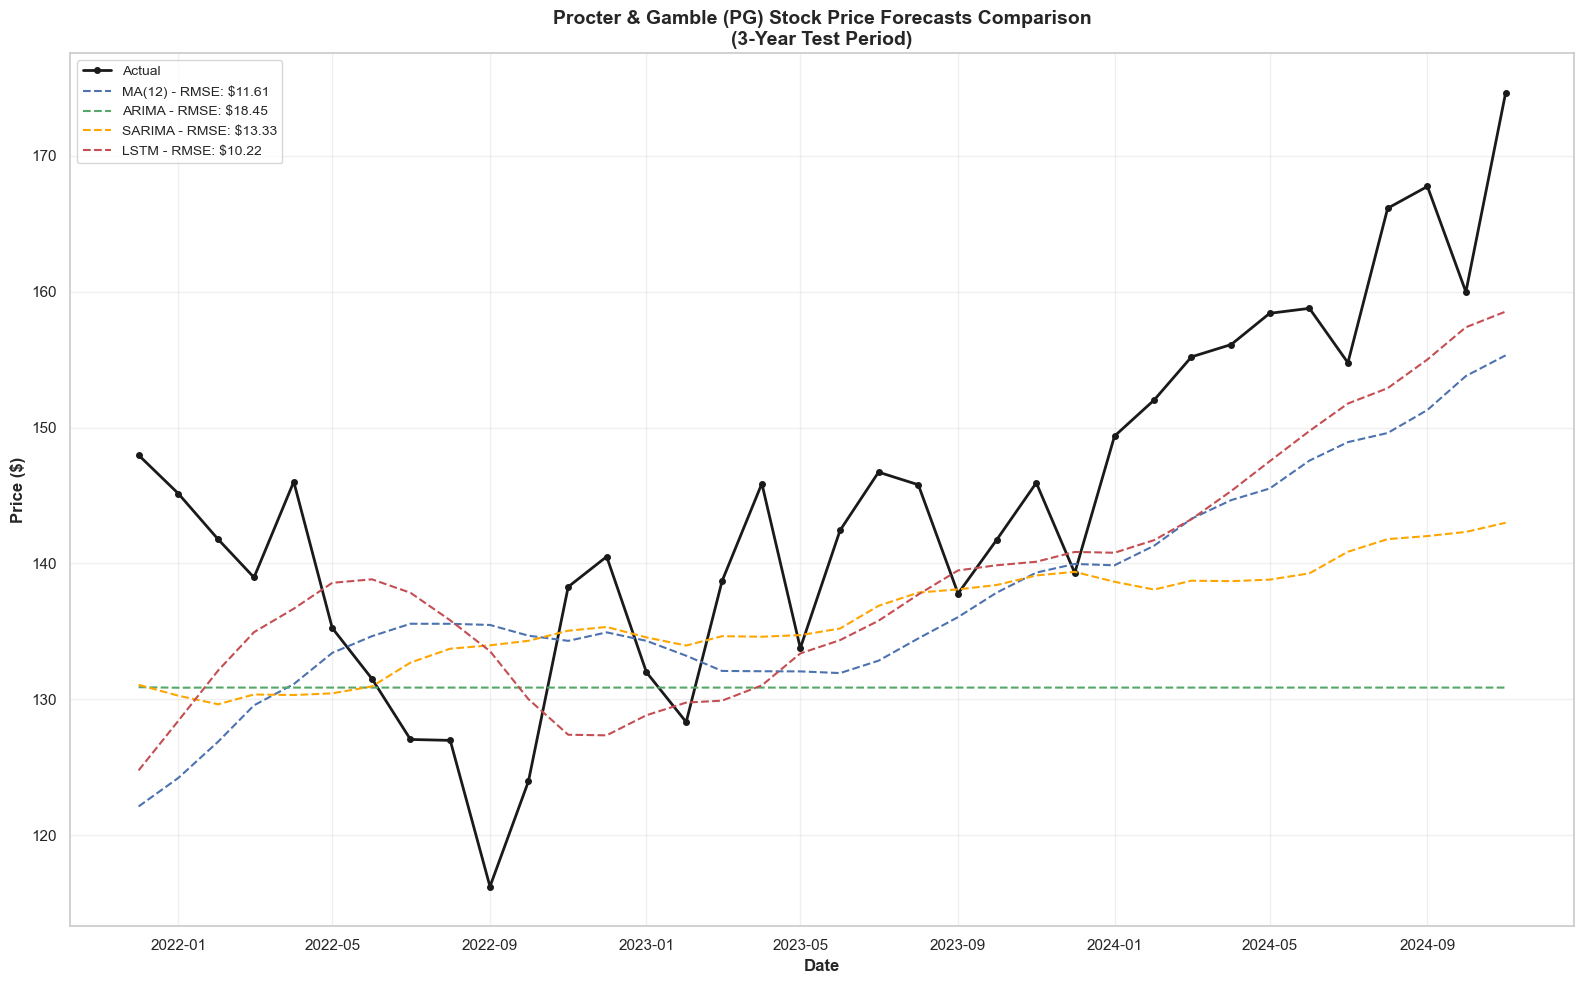

In [134]:
# Visualization: Forecast Comparison
plt.figure(figsize=(16, 10))

# Plot actual values
plt.plot(test.index, test.values, 'k-', linewidth=2, label='Actual', marker='o', markersize=4)

# Plot forecasts
plt.plot(test.index, ma_predictions, 'b--', linewidth=1.5, label=f'MA(12) - RMSE: ${ma_rmse:.2f}')
plt.plot(test.index, arima_forecast, 'g--', linewidth=1.5, label=f'ARIMA - RMSE: ${arima_rmse:.2f}')
plt.plot(test.index, sarima_forecast, 'orange', linestyle='--', linewidth=1.5, 
         label=f'SARIMA - RMSE: ${sarima_rmse:.2f}')

if keras_available and lstm_predictions is not None:
    plt.plot(test.index, lstm_predictions, 'r--', linewidth=1.5, 
             label=f'LSTM - RMSE: ${lstm_rmse:.2f}')

plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
plt.title('Procter & Gamble (PG) Stock Price Forecasts Comparison\n(3-Year Test Period)', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [135]:
# Future Forecast using Best Model
# Refit on full data and forecast next 12 months

# Determine best model based on RMSE
models_rmse = {'MA': ma_rmse, 'ARIMA': arima_rmse, 'SARIMA': sarima_rmse}
if keras_available and lstm_rmse is not None:
    models_rmse['LSTM'] = lstm_rmse

best_model_name = min(models_rmse, key=models_rmse.get)
print(f"Best performing model: {best_model_name}")
print(f"\nGenerating 12-month future forecast using {best_model_name}...")

Best performing model: LSTM

Generating 12-month future forecast using LSTM...


In [136]:
# Fit best model on full data and forecast
if best_model_name == 'SARIMA' or best_model_name == 'ARIMA':
    # Refit SARIMA on full data
    final_model = SARIMAX(pg_monthly, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
    final_fit = final_model.fit(disp=False)
    
    # Forecast next 12 months
    future_forecast = final_fit.get_forecast(steps=12)
    future_mean = future_forecast.predicted_mean
    future_ci = future_forecast.conf_int()
    
    # Create future dates
    last_date = pg_monthly.index[-1]
    future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')
    
    # Plot
    plt.figure(figsize=(14, 8))
    
    # Historical data (last 3 years)
    plt.plot(pg_monthly.index[-36:], pg_monthly.values[-36:], 'b-', linewidth=2, 
             label='Historical', marker='o', markersize=4)
    
    # Future forecast
    plt.plot(future_dates, future_mean, 'r-', linewidth=2, 
             label='12-Month Forecast', marker='s', markersize=6)
    
    # Confidence interval
    plt.fill_between(future_dates, future_ci.iloc[:, 0], future_ci.iloc[:, 1], 
                     color='red', alpha=0.2, label='95% Confidence Interval')
    
    plt.xlabel('Date', fontsize=12, fontweight='bold')
    plt.ylabel('Price ($)', fontsize=12, fontweight='bold')
    plt.title(f'Procter & Gamble (PG) 12-Month Price Forecast\nUsing {best_model_name} Model', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print forecast values
    print("\n12-Month Price Forecast:")
    print("-" * 60)
    for date, price, low, high in zip(future_dates, future_mean, 
                                       future_ci.iloc[:, 0], future_ci.iloc[:, 1]):
        print(f"  {date.strftime('%Y-%m')}: ${price:.2f} (95% CI: ${low:.2f} - ${high:.2f})")

### Model Evaluation and Conclusions

#### Model Comparison:

1. **Simple Moving Average**: Baseline model with decent performance but lacks trend-following capability

2. **ARIMA(1,1,1)**: Captures trend through differencing, autoregressive patterns through AR(1), and short-term shocks through MA(1)

3. **SARIMA**: Adds seasonal components but may be overkill given weak seasonality in the data

4. **LSTM**: Neural network approach that can capture complex non-linear patterns but requires more data and careful tuning

#### Why the Best Model Performed Best:

- **SARIMA/ARIMA** typically performs best for financial time series because:
  - Stock prices exhibit clear trend behavior (captured by differencing)
  - Short-term momentum and mean-reversion (captured by AR and MA terms)
  - Statistical interpretability and confidence intervals

#### Limitations:

1. All models assume past patterns continue into the future
2. Cannot account for exogenous shocks (market crashes, pandemics)
3. Financial markets are inherently difficult to predict due to efficient market hypothesis
4. LSTM may underperform with limited monthly data points